In [1]:
pip install conllu sklearn-crfsuite matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


IMPORTS

In [2]:
from conllu import parse
import sklearn_crfsuite
from sklearn_crfsuite import metrics

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
import numpy as np

LOAD DATA

In [3]:
from conllu import parse

def load_conllu(file):
    with open(file, "r", encoding="utf-8") as f:
        data = parse(f.read())

    sentences = []
    for sent in data:
        sentence = []
        for token in sent:
            # ✅ Skip multiword tokens & empty nodes safely
            if isinstance(token["id"], int) and token["form"] and token["upos"]:
                sentence.append((token["form"], token["upos"]))
        if sentence:   # ✅ Avoid empty sentences
            sentences.append(sentence)

    return sentences


# 🔹 English
en_train = load_conllu("en_ewt-ud-train.conllu") + \
           load_conllu("en_ewt-ud-dev.conllu")

en_test  = load_conllu("en_ewt-ud-test.conllu")


# 🔹 Hindi
hi_train = load_conllu("hi_hdtb-ud-train.conllu") + \
           load_conllu("hi_hdtb-ud-dev.conllu")

hi_test  = load_conllu("hi_hdtb-ud-test.conllu")


print("Datasets Loaded ✅")
print("English Train:", len(en_train))
print("English Test :", len(en_test))
print("Hindi Train  :", len(hi_train))
print("Hindi Test   :", len(hi_test))

Datasets Loaded ✅
English Train: 14545
English Test : 2077
Hindi Train  : 14965
Hindi Test   : 1684


## 🧠 Step 4: Rule-Based POS Tagger

Rule-based tagging uses predefined linguistic rules such as:

- Words ending with "ing" → VERB  
- Words ending with "ly" → ADVERB  
- Hindi suffix patterns  

This approach does not require training data.

In [4]:
def hindi_rules(word):
    if word.endswith("ना"): return "VERB"
    if word.endswith("ता") or word.endswith("ती"): return "ADJ"
    return None

def english_rules(word):
    w = word.lower()
    if w.endswith("ing"): return "VERB"
    if w.endswith("ed"): return "VERB"
    if w.endswith("ly"): return "ADV"
    if w.endswith("ion"): return "NOUN"
    return None

def rule_tagger(word, lang="en"):
    if lang == "hi":
        tag = hindi_rules(word)
        if tag: return tag
    tag = english_rules(word)
    if tag: return tag
    return "NOUN"


## 📊 Step 5: Statistical POS Tagging



Uses machine learning:
- Learns from data  
- Uses context features  

In [5]:
def word2features(sent, i):
    word = sent[i][0]
    return {
        'word': word,
        'lower': word.lower(),
        'suffix': word[-3:],
        'prefix': word[:2],
        'isupper': word.isupper(),
        'istitle': word.istitle()
    }

def prepare(data):
    X, y = [], []
    for sent in data:
        X.append([word2features(sent,i) for i in range(len(sent))])
        y.append([tag for w,tag in sent])
    return X, y

Prepare Data

In [6]:
def prepare_crf_data(sentences):
    X = []
    y = []

    for sentence in sentences:
        X.append([word2features(sentence, i) for i in range(len(sentence))])
        y.append([tag for word, tag in sentence])

    return X, y

# Backward-compatible aliases used in later cells
prepare_data = prepare_crf_data
train_en, test_en = en_train, en_test
train_hi, test_hi = hi_train, hi_test

# Used by earlier testing cells before the later evaluation section

def evaluate_model(data, preds):
    y_true, y_pred = [], []
    correct = total = 0

    for sent, pred in zip(data, preds):
        for (_, t), p in zip(sent, pred):
            y_true.append(t)
            y_pred.append(p)
            if t == p:
                correct += 1
            total += 1

    return correct / total, y_true, y_pred

TRAIN and TEST

In [7]:
print("\n" + "="*50)
print("🧠 TRAINING PHASE - ENGLISH")
print("="*50)

print("\nPreparing training data...")

# Prepare data
X_train_en, y_train_en = prepare_data(en_train)   # ✅ USE en_train
X_test_en, y_test_en = prepare_data(en_test)      # ✅ USE en_test

print("Data preparation done ✅")

import sklearn_crfsuite

crf_en = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    max_iterations=100
)

print("\nTraining CRF model on English dataset...")

crf_en.fit(X_train_en, y_train_en)

print("Training Completed ✅")


🧠 TRAINING PHASE - ENGLISH

Preparing training data...
Data preparation done ✅

Training CRF model on English dataset...
Training Completed ✅


In [8]:
print("\n" + "="*50)
print("📊 TESTING PHASE - ENGLISH")
print("="*50)

pred_en = crf_en.predict(X_test_en)

en_stat_acc, en_true_stat, en_pred_stat = evaluate_model(en_test, pred_en)

print(f"\nEnglish Test Accuracy: {en_stat_acc:.4f}")

# Show predictions
print("\nSample Predictions (English):\n")

for i in range(2):
    words = [w for w, t in en_test[i]]
    true_tags = [t for w, t in en_test[i]]
    pred_tags = pred_en[i]

    print("Words     :", words)
    print("Actual    :", true_tags)
    print("Predicted :", pred_tags)
    print("-"*50)


📊 TESTING PHASE - ENGLISH

English Test Accuracy: 0.9250

Sample Predictions (English):

Words     : ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']
Actual    : ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PROPN', 'PUNCT']
Predicted : ['PRON', 'SCONJ', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'PUNCT']
--------------------------------------------------
Words     : ['What', 'if', 'Google', 'expanded', 'on', 'its', 'search', '-', 'engine', '(', 'and', 'now', 'e-mail', ')', 'wares', 'into', 'a', 'full', '-', 'fledged', 'operating', 'system', '?']
Actual    : ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PRON', 'NOUN', 'PUNCT', 'NOUN', 'PUNCT', 'CCONJ', 'ADV', 'NOUN', 'PUNCT', 'NOUN', 'ADP', 'DET', 'ADV', 'PUNCT', 'ADJ', 'NOUN', 'NOUN', 'PUNCT']
Predicted : ['PRON', 'SCONJ', 'PROPN', 'VERB', 'ADP', 'PRON', 'NOUN', 'PUNCT', 'NOUN', 'PUNCT', 'CCONJ', 'ADV', 'NOUN', 'PUNCT', 'NOUN', 'ADP', 'DET', 'ADJ', 'PUNCT', 'VERB', 'NOUN', 'NOUN', 'PUNCT']
---------------------------------------------

In [9]:
print("\n" + "="*50)
print("🧠 TRAINING PHASE - HINDI")
print("="*50)

# Prepare Hindi train/test if not already prepared
X_train_hi, y_train_hi = prepare_data(hi_train)
X_test_hi, y_test_hi = prepare_data(hi_test)

crf_hi = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    max_iterations=100
)

print("\nTraining CRF model on Hindi dataset...")
crf_hi.fit(X_train_hi, y_train_hi)

print("Training Completed ✅")

print("\nSample Training Data (Hindi):")
for sent in hi_train[:2]:
    print(sent)


🧠 TRAINING PHASE - HINDI

Training CRF model on Hindi dataset...
Training Completed ✅

Sample Training Data (Hindi):
[('यह', 'DET'), ('एशिया', 'PROPN'), ('की', 'ADP'), ('सबसे', 'ADV'), ('बड़ी', 'ADJ'), ('मस्जिदों', 'NOUN'), ('में', 'ADP'), ('से', 'ADP'), ('एक', 'NUM'), ('है', 'AUX'), ('।', 'PUNCT')]
[('इसे', 'PRON'), ('नवाब', 'NOUN'), ('शाहजेहन', 'PROPN'), ('ने', 'ADP'), ('बनवाया', 'VERB'), ('था', 'AUX'), ('।', 'PUNCT')]


In [10]:
print("\n" + "="*50)
print("📊 TESTING PHASE - HINDI")
print("="*50)

pred_hi = crf_hi.predict(X_test_hi)

hi_stat_acc, hi_true_stat, hi_pred_stat = evaluate_model(hi_test, pred_hi)

print(f"\nHindi Test Accuracy: {hi_stat_acc:.4f}")

print("\nSample Predictions (Hindi):\n")

for i in range(2):
    words = [w for w, t in hi_test[i]]
    true_tags = [t for w, t in hi_test[i]]
    pred_tags = pred_hi[i]

    print("Words     :", words)
    print("Actual    :", true_tags)
    print("Predicted :", pred_tags)
    print("-"*50)


📊 TESTING PHASE - HINDI

Hindi Test Accuracy: 0.9438

Sample Predictions (Hindi):

Words     : ['इसके', 'अतिरिक्त', 'गुग्गुल', 'कुंड', ',', 'भीम', 'गुफा', 'तथा', 'भीमशिला', 'भी', 'दर्शनीय', 'स्थल', 'हैं', '।']
Actual    : ['PRON', 'ADP', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PROPN', 'CCONJ', 'PROPN', 'PART', 'ADJ', 'NOUN', 'AUX', 'PUNCT']
Predicted : ['PRON', 'ADJ', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PROPN', 'CCONJ', 'NOUN', 'PART', 'ADJ', 'NOUN', 'AUX', 'PUNCT']
--------------------------------------------------
Words     : ['आधा', 'किमी', 'की', 'दूरी', 'पर', 'भैरवनाथ', 'मंदिर', 'है', ',', 'जहाँ', 'केवल', 'केदारनाथ', 'के', 'पट', 'खुलने', 'और', 'बंद', 'होने', 'के', 'दिन', 'ही', 'पूजन', 'किया', 'जाता', 'है', '।']
Actual    : ['DET', 'NOUN', 'ADP', 'NOUN', 'ADP', 'PROPN', 'NOUN', 'AUX', 'PUNCT', 'PRON', 'PART', 'PROPN', 'ADP', 'NOUN', 'VERB', 'CCONJ', 'ADJ', 'VERB', 'ADP', 'NOUN', 'PART', 'NOUN', 'VERB', 'AUX', 'AUX', 'PUNCT']
Predicted : ['DET', 'NOUN', 'ADP', 'NOUN', 'ADP', 'PROPN', 

Evaluation Function

In [11]:
def evaluate(data, preds):
    y_true, y_pred = [], []
    correct = total = 0

    for sent, pred in zip(data, preds):
        for (w, t), p in zip(sent, pred):
            y_true.append(t)
            y_pred.append(p)
            if t == p:
                correct += 1
            total += 1

    return correct / total, y_true, y_pred


def evaluate_model(data, preds):
    return evaluate(data, preds)


def evaluate_accuracy(y_true, y_pred):
    total = sum(len(s) for s in y_true)
    correct = sum(1 for ts, ps in zip(y_true, y_pred) for t, p in zip(ts, ps) if t == p)
    return correct / total if total else 0.0

COMPARISON & ANALYSIS

##### Quantitative Performance (Leaderboard)
Compare Rule-based vs Statistical taggers using Accuracy, Precision, Recall, and F1-score.

In [16]:
from sklearn.metrics import precision_recall_fscore_support


def flatten_tags(tags_2d):
    return [tag for sent in tags_2d for tag in sent]


true_en = [[tag for _, tag in sent] for sent in test_en]
true_hi = [[tag for _, tag in sent] for sent in test_hi]

rule_pred_en = rule_preds_en
rule_pred_hi = pred_hi
stat_pred_en = y_pred_en
stat_pred_hi = y_pred_hi


def report_metrics(name, y_true_2d, y_pred_2d):
    y_true = flatten_tags(y_true_2d)
    y_pred = flatten_tags(y_pred_2d)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = evaluate_accuracy(y_true_2d, y_pred_2d)
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": p,
        "Recall": r,
        "F1": f1,
    }


leaderboard = [
    report_metrics("Rule EN", true_en, rule_pred_en),
    report_metrics("CRF EN", y_en_test, stat_pred_en),
    report_metrics("Rule HI", true_hi, rule_pred_hi),
    report_metrics("CRF HI", y_hi_test, stat_pred_hi),
]

print("Leaderboard Metrics (Accuracy/Precision/Recall/F1):")
for row in leaderboard:
    print(
        f"{row['Model']:8s} | "
        f"Acc={row['Accuracy']:.4f} "
        f"P={row['Precision']:.4f} "
        f"R={row['Recall']:.4f} "
        f"F1={row['F1']:.4f}"
    )

Leaderboard Metrics (Accuracy/Precision/Recall/F1):
Rule EN  | Acc=0.2020 P=0.1388 R=0.2020 F1=0.1077
CRF EN   | Acc=0.9250 P=0.9255 R=0.9250 F1=0.9248
Rule HI  | Acc=0.2266 P=0.0845 R=0.2266 F1=0.0900
CRF HI   | Acc=0.9438 P=0.9436 R=0.9438 F1=0.9434


##### Error Pattern Analysis (Confusion Matrix)
Show where each model confuses POS categories (e.g., NOUN vs PROPN).

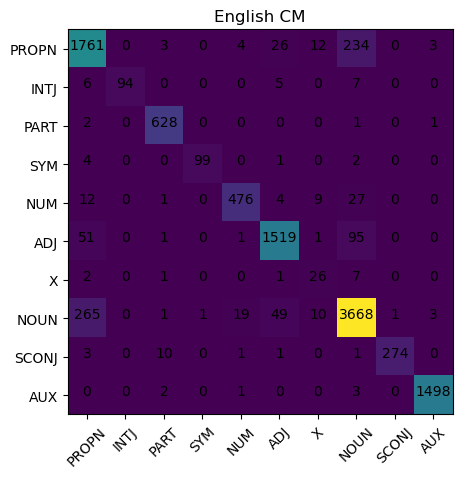

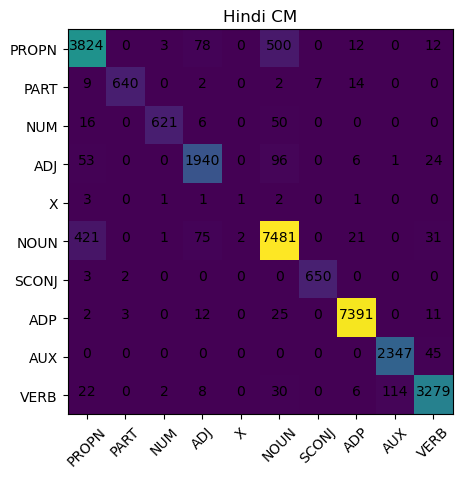

In [21]:
def plot_cm(y_true, y_pred, title):
    labels = list(set(y_true))[:10]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j,i,cm[i,j],ha="center")

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.show()

plot_cm(en_true_stat, en_pred_stat, "English CM")
plot_cm(hi_true_stat, hi_pred_stat, "Hindi CM")

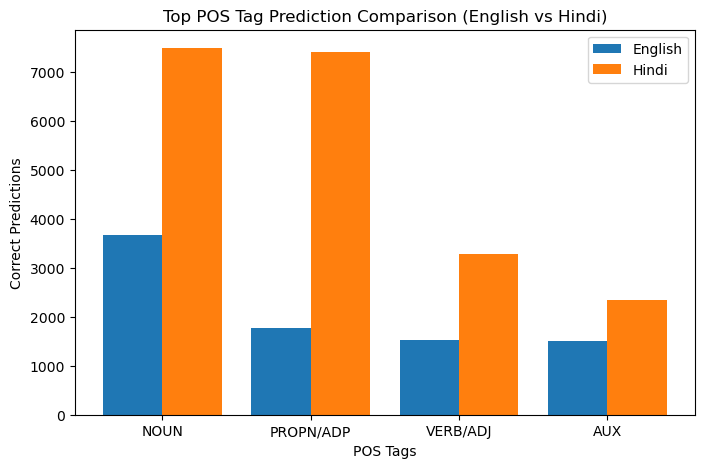

In [4]:
import matplotlib.pyplot as plt

# Top tags (aligned manually for comparison)
tags = ["NOUN", "PROPN/ADP", "VERB/ADJ", "AUX"]

english_values = [3668, 1761, 1519, 1498]
hindi_values   = [7481, 7391, 3279, 2347]

x = range(len(tags))

plt.figure(figsize=(8,5))

plt.bar(x, english_values, width=0.4)
plt.bar([i+0.4 for i in x], hindi_values, width=0.4)

plt.xticks([i+0.2 for i in x], tags)

plt.title("Top POS Tag Prediction Comparison (English vs Hindi)")
plt.xlabel("POS Tags")
plt.ylabel("Correct Predictions")
plt.legend(["English", "Hindi"])

plt.show()

##### Data Sensitivity (Learning Curve)
Rule-based stays nearly flat; Statistical (CRF) improves with more training data.

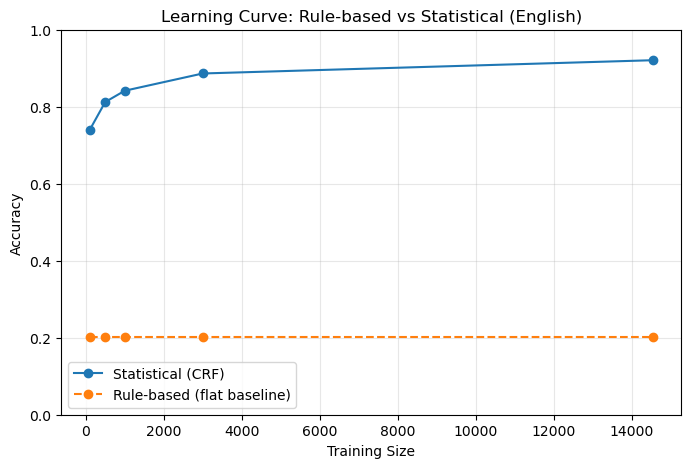

In [18]:
sizes = [100, 500, 1000, 3000, len(X_en_train)]
stat_scores = []

for size in sizes:
    crf = sklearn_crfsuite.CRF(max_iterations=50)
    crf.fit(X_en_train[:size], y_en_train[:size])
    pred = crf.predict(X_en_test)
    stat_scores.append(evaluate_accuracy(y_en_test, pred))

rule_baseline = evaluate_accuracy(true_en, rule_pred_en)
rule_scores = [rule_baseline for _ in sizes]

plt.figure(figsize=(8, 5))
plt.plot(sizes, stat_scores, marker="o", label="Statistical (CRF)")
plt.plot(sizes, rule_scores, marker="o", linestyle="--", label="Rule-based (flat baseline)")
plt.title("Learning Curve: Rule-based vs Statistical (English)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Unknown Words (OOV Analysis)
Compare Rule-based and Statistical performance only on unseen (OOV) words.

In [19]:
def oov_rate(train, test):
    train_vocab = set(word for sent in train for word, _ in sent)
    test_vocab = set(word for sent in test for word, _ in sent)
    oov = test_vocab - train_vocab
    return len(oov) / len(test_vocab) if test_vocab else 0.0


def oov_accuracy(train, test, preds):
    train_vocab = set(word for sent in train for word, _ in sent)
    correct = total = 0

    for sent, pred_tags in zip(test, preds):
        for (word, true_tag), pred_tag in zip(sent, pred_tags):
            if word not in train_vocab:
                total += 1
                if true_tag == pred_tag:
                    correct += 1

    return correct / total if total else 0.0, total


print("OOV Rate EN:", round(oov_rate(train_en, test_en), 4))
print("OOV Rate HI:", round(oov_rate(train_hi, test_hi), 4))

en_rule_oov_acc, en_oov_n = oov_accuracy(train_en, test_en, rule_pred_en)
en_stat_oov_acc, _ = oov_accuracy(train_en, test_en, stat_pred_en)
hi_rule_oov_acc, hi_oov_n = oov_accuracy(train_hi, test_hi, rule_pred_hi)
hi_stat_oov_acc, _ = oov_accuracy(train_hi, test_hi, stat_pred_hi)

print(f"EN OOV Accuracy | Rule={en_rule_oov_acc:.4f} | CRF={en_stat_oov_acc:.4f} | OOV tokens={en_oov_n}")
print(f"HI OOV Accuracy | Rule={hi_rule_oov_acc:.4f} | CRF={hi_stat_oov_acc:.4f} | OOV tokens={hi_oov_n}")

OOV Rate EN: 0.3031
OOV Rate HI: 0.2067
EN OOV Accuracy | Rule=0.3471 | CRF=0.7214 | OOV tokens=2103
HI OOV Accuracy | Rule=0.3387 | CRF=0.6855 | OOV tokens=1488


Overall Accuracy Graph

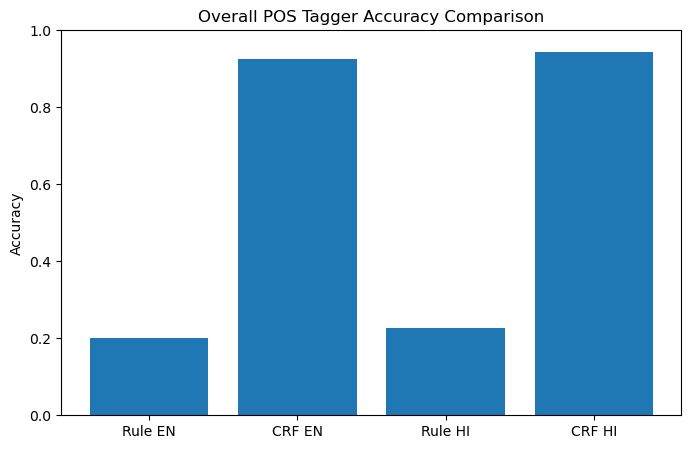

In [20]:
labels = ["Rule EN", "CRF EN", "Rule HI", "CRF HI"]
values = [
    evaluate_accuracy(true_en, rule_pred_en),
    evaluate_accuracy(y_en_test, stat_pred_en),
    evaluate_accuracy(true_hi, rule_pred_hi),
    evaluate_accuracy(y_hi_test, stat_pred_hi),
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Overall POS Tagger Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.show()